In [63]:
cd /lustre/fsn1/projects/rech/omr/romr004/code/DINO-Fusion/

/lustre/fsn1/projects/rech/omr/romr004/code/DINO-Fusion


In [2]:
import importlib
import sys; from __init__ import PRP

sys.path.append(f'{PRP}/../dinostics/')
import experiment
importlib.reload(experiment)  # optional if editing without restart
from experiment import NemoExperiment

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mplcolors
import cmocean as cm

# Load experiments

In [4]:
base_path = '/lustre/fsstor/projects/rech/omr/uym68qx/nemo_output/DINO/Dinoffusion/'
blandine_base = '/lustre/fsn1/projects/rech/omr/romr004/Blandine/DINO/Diffusion_runs/'
blandine_base_david = '/lustre/fsn1/projects/rech/omr/uym68qx/DINO/Blandine/'

#'/lustre/fsn1/projects/rech/omr/uym68qx/DINO/'

In [46]:
#'/lustre/fswork/projects/rech/omr/uym68qx/data/'

expR4 = NemoExperiment(
    path= base_path,
    experiment_name='1_4degree',
    restarts=['restart25', 'restart26', 'restart27', 'restart28','restart29'],
    files = ['T_3D']
)

expR4.data['inst_T_3D'] = expR4.data['T_3D'] 
expR4.data['T_3D'] = expR4.data['inst_T_3D'].groupby('t.year').mean(dim='t')
expR4.data['T_3D'] = expR4.data['T_3D'].rename({'year': 't'})
expR4.data['T_3D'] = expR4.data['T_3D'].rename({'toce_inst': 'toce', 'soce_inst': 'soce'})

expR4.description = 'Simulation 1/4 degree'
expR4.namelist['namrun']['nn_itend'] = 12960000 # Here we didn't have the right end for some reason 


# expC1 = NemoExperiment(
#     path= blandine_base,
#     experiment_name='Blandine',
#     restarts=['restart25_C1'],
#     files = ['inst_T_3D', 'T_3D']
# )

# expC1.description = 'Diffusion Constraint 1'

# expC2 = NemoExperiment(
#     path= blandine_base,
#     experiment_name='Blandine',
#     restarts=['restart25_C2'],
#     files = ['inst_T_3D', 'T_3D']
# )

# expC2.description = 'Diffusion Constraint 2'

expnoC = NemoExperiment(
    path= blandine_base,
    experiment_name='Constraint_no_C',
    restarts=['restart0'],
    files = ['inst_T_3D', 'T_3D']
)

expnoC.description = 'No constraint'

expCTS = NemoExperiment(
    path= blandine_base,
    experiment_name='Constraint_TS',
    restarts=['restart0'],
    files = ['inst_T_3D', 'T_3D']
)

expCTS.description = 'Constraint TS'

expC1 = NemoExperiment(
    path= blandine_base_david,
    experiment_name='',
    restarts=['restart25_C1'],
    files = ['inst_T_3D', 'T_3D']
)

expC1.namelist['namrun']['cn_ocerst_in'] = 'diffusion_states/' + expC1.namelist['namrun']['cn_ocerst_in']
expC1.description = 'Constraint C1'

expC2 = NemoExperiment(
    path= blandine_base_david,
    experiment_name='',
    restarts=['restart25_C2'],
    files = ['inst_T_3D', 'T_3D']
)

expC2.namelist['namrun']['cn_ocerst_in'] = 'diffusion_states/' + expC2.namelist['namrun']['cn_ocerst_in']
expC2.description = 'Constraint C2'


exps = [expnoC, expCTS, expC1, expC2]

'restart0'

# Figures using yearly average

In [23]:
for exp in exps :
    s = exp.diagnostics.get_rho(T=exp.data['T_3D'].toce,
                                  S=exp.data['T_3D'].soce,
                                  z=2000.).where(exp.mask.tmask==1.0).mean('x_c')
    
    s = s.assign_coords(lat=exp.data['T_3D'].gphit.isel(x_c=10),
                        depth_plot=('z_c',exp.mask.gdepw_1d.shift(z_f=-1, fill_value=4250.).values)) - 1000
    
    exp.data['T_3D']['Sigma'] = s

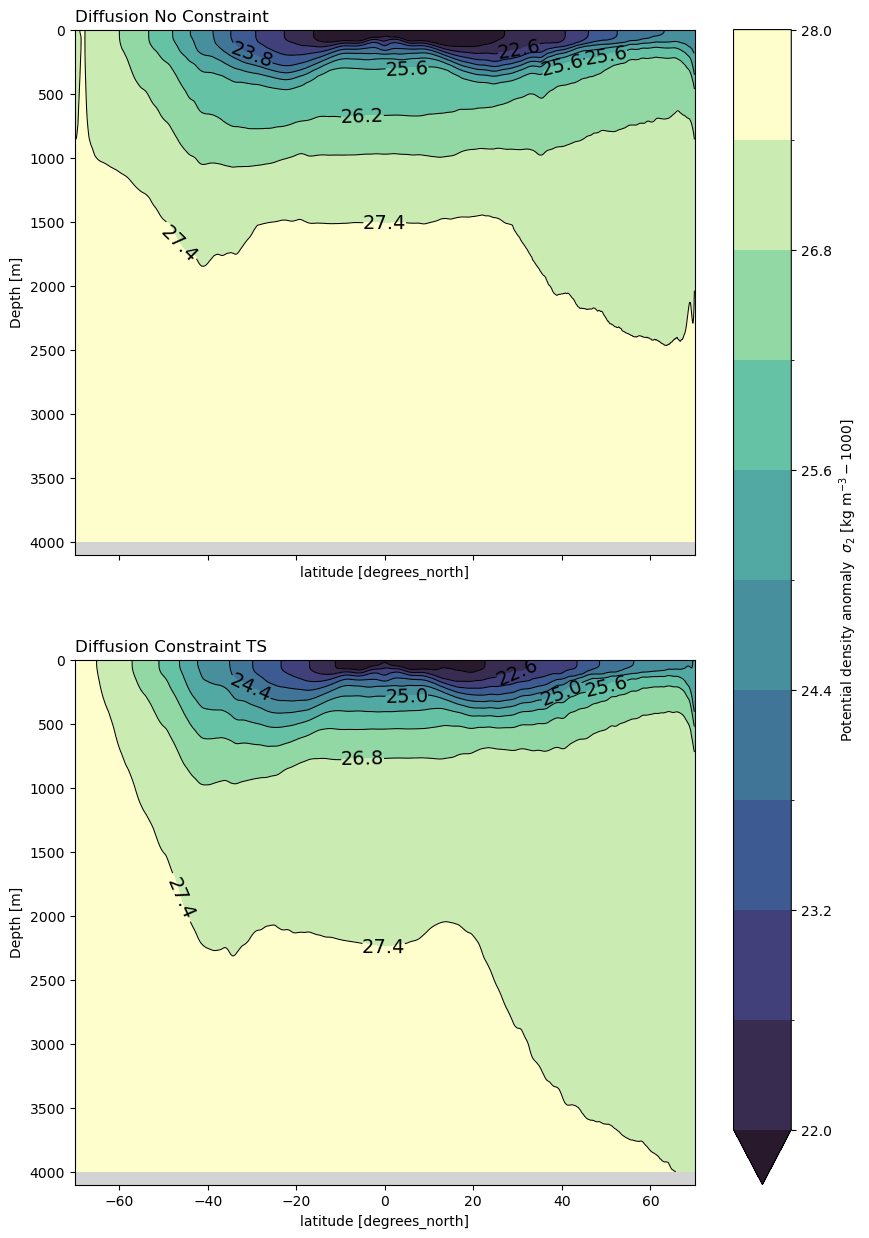

In [24]:
fig_dense, axs = plt.subplots(len(exps),1, figsize=(10,15), sharex=True, sharey=True)
levels = np.linspace(22.,28.,11)

for i, exp in enumerate(exps) :
    sigma_mean = exp.data['T_3D'].Sigma.isel(t=slice(-2, -1)).mean('t').compute()
    
    a = sigma_mean.plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat',
                                 y='depth_plot', ax=axs[i], add_colorbar=False, yincrease=False)
    
    contour_1 = sigma_mean.plot.contour(levels=levels, colors='k', linewidths=0.75,
                                        x='lat', y='depth_plot', ax=axs[i], yincrease=False)
    
    plt.clabel(contour_1, fmt="%.1f", inline=True, fontsize=14,
               manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (40,250)])
    axs[i].set_ylabel(r'Depth [m]')
    axs[i].set_title(exp.description, loc='left')
    axs[i].set_facecolor("lightgray")
    axs[i].set_ylim(4100,0)

    #axs[i].set_xlabel('')
    #axs[1].set_xlabel(r'Latitude [$^{\circ} \, \text{N}$]')

cbar1 = fig_dense.colorbar(a, ax=axs, label=r'Potential density anomaly  $\sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')


# Figures using daily avgs

In [25]:
for exp in exps :
    s = exp.diagnostics.get_rho(T=exp.data['inst_T_3D'].toce_inst,
                                  S=exp.data['inst_T_3D'].soce_inst,
                                  z=2000.).where(exp.mask.tmask==1.0).mean('x_c')
    
    s = s.assign_coords(lat=exp.data['inst_T_3D'].gphit.isel(x_c=10),
                        depth_plot=('z_c',exp.mask.gdepw_1d.shift(z_f=-1, fill_value=4250.).values)) - 1000
    
    exp.data['inst_T_3D']['Sigma'] = s

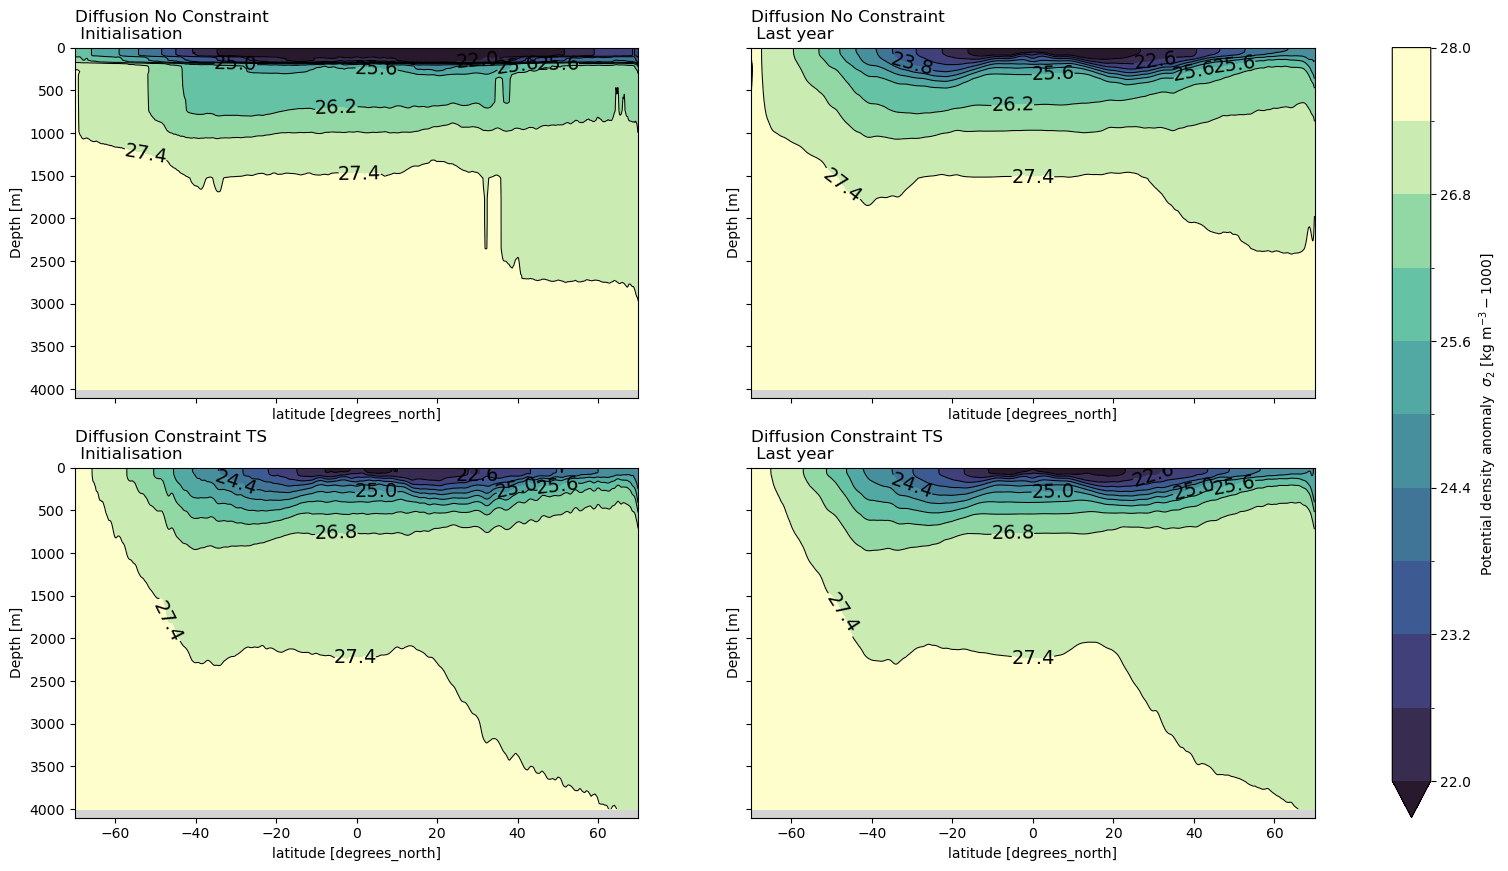

In [26]:
fig_dense, axs = plt.subplots(len(exps), 2, figsize=(20, 10), sharex=True, sharey=True)
levels = np.linspace(22.,28,11)

for i, exp in enumerate(exps) :
    for j, s in enumerate([{'name' : 'Initialisation', 'slice' : slice(0,1)},
                           {'name' : 'Last year', 'slice' : slice(-36, -1)}]) : 
        
        sigma_mean = exp.data['inst_T_3D'].Sigma.isel(t=s['slice']).mean('t').compute()
            
        a = sigma_mean.plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat',
                                     y='depth_plot', ax=axs[i, j], add_colorbar=False, yincrease=False)
        
        contour_1 = sigma_mean.plot.contour(levels=levels, colors='k', linewidths=0.75,
                                            x='lat', y='depth_plot', ax=axs[i, j], yincrease=False)
        
        plt.clabel(contour_1, fmt="%.1f", inline=True, fontsize=14,
                   manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (40,250)])

        axs[i, j].set_ylabel(r'Depth [m]')
        axs[i, j].set_title(f'{exp.description} \n {s["name"]}', loc='left')
        axs[i, j].set_facecolor("lightgray")
        axs[i, j].set_ylim(4100,0)
        
cbar1 = fig_dense.colorbar(a, ax=axs, label=r'Potential density anomaly  $\sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')


# Figure Initial States

In [47]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def prepare_restart(exp, restart_path) :
    """
    Load restart file, convert coordinates and compute Sigma
    """
    rn = exp.open_restart(restart_path)
    
    # New coordinate z_c
    z_c = exp.data['inst_T_3D'].toce_inst.z_c
    rn = rn.drop_vars('nav_lev')
    rn = rn.rename({"nav_lev": "z_c", "y" : "y_c", "x" : "x_c"})
    rn = rn.assign_coords(z_c=z_c)
    return rn

def compute_sigma_mean(exp, rn) : 
    # Compute Sigma
    s = exp.diagnostics.get_rho(T=rn.tn,
                                S=rn.sn,
                                z=2000.).where(exp.mask.tmask==1.0).mean('x_c')
        
    s = s.assign_coords(lat=exp.data['inst_T_3D'].gphit.isel(x_c=10),
                        depth_plot=('z_c',expnoC.mask.gdepw_1d.shift(z_f=-1, fill_value=4250.).values)) - 1000
    return s.isel(time_counter=0).compute()

def add_sigma_plot(ax, sigma_mean, title) :
    levels = np.linspace(22.,28.5,14)
    a = sigma_mean.plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat',
                                 y='depth_plot', ax=ax, add_colorbar=False, yincrease=False)
    contour_1 = sigma_mean.plot.contour(levels=levels, colors='k', linewidths=0.75,
                                        x='lat', y='depth_plot', ax=ax, yincrease=False)
    sigma_profile = sigma_mean.mean('y_c').compute()


    # Vertical dashed lines
    ax.axvline(x=-65, color='gray', linestyle='dashed')
    ax.axvline(x=-45, color='gray', linestyle='dashed')
    ax.set_title('')
    ax.set_title(title, loc='left')
    ax.set_ylim(3500,0)


    # Compute x-average between lat indices
    lat_vals = sigma_mean.lat.values
    idx_min = np.argmin(np.abs(lat_vals + 65))  # Find index for -65
    idx_max = np.argmin(np.abs(lat_vals + 45))  # Find index for -45
    subset = sigma_mean.isel(y_c=slice(idx_min, idx_max)).mean(dim='y_c')
   # subset = sigma_mean.mean(dim='y_c')

    # Inset plot (on the right)
    inset_ax = inset_axes(ax, width="15%", height="100%", loc='right', borderpad=2)
    inset_ax.plot(subset, subset['depth_plot'], color='black', linewidth=2)
    inset_ax.patch.set_alpha(0.75)


    # **Ensure y-axis matches main plot**
    inset_ax.set_ylim(ax.get_ylim())  
    inset_ax.set_yticks(ax.get_yticks())  
    inset_ax.set_yticklabels([])  # Remove y labels for clarity
    inset_ax.set_xticklabels([])  # Remove x labels
    inset_ax.grid(True, linestyle="--", alpha=0.5)

    ax.set_title(title, loc='left')
    return a

[PurePosixPath('/lustre/fsn1/projects/rech/omr/romr004/data/diffusion_states/generated_restart_no_C_1_4deg.nc')]


/lustre/fsn1/projects/rech/omr/romr004/code/ZB_DINO//../dinostics/experiment.py:120: UserWarning: The specified chunks separate the stored chunks along dimension "nav_lev" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


[PurePosixPath('/lustre/fsn1/projects/rech/omr/romr004/data/diffusion_states/generated_restart_TS_1_4deg.nc')]


/lustre/fsn1/projects/rech/omr/romr004/code/ZB_DINO//../dinostics/experiment.py:120: UserWarning: The specified chunks separate the stored chunks along dimension "nav_lev" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


[PurePosixPath('/lustre/fsn1/projects/rech/omr/romr004/data/diffusion_states/generated_C1_restart.nc')]


/lustre/fsn1/projects/rech/omr/romr004/code/ZB_DINO//../dinostics/experiment.py:120: UserWarning: The specified chunks separate the stored chunks along dimension "nav_lev" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


[PurePosixPath('/lustre/fsn1/projects/rech/omr/romr004/data/diffusion_states/generated_C2_restart.nc')]


/lustre/fsn1/projects/rech/omr/romr004/code/ZB_DINO//../dinostics/experiment.py:120: UserWarning: The specified chunks separate the stored chunks along dimension "nav_lev" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


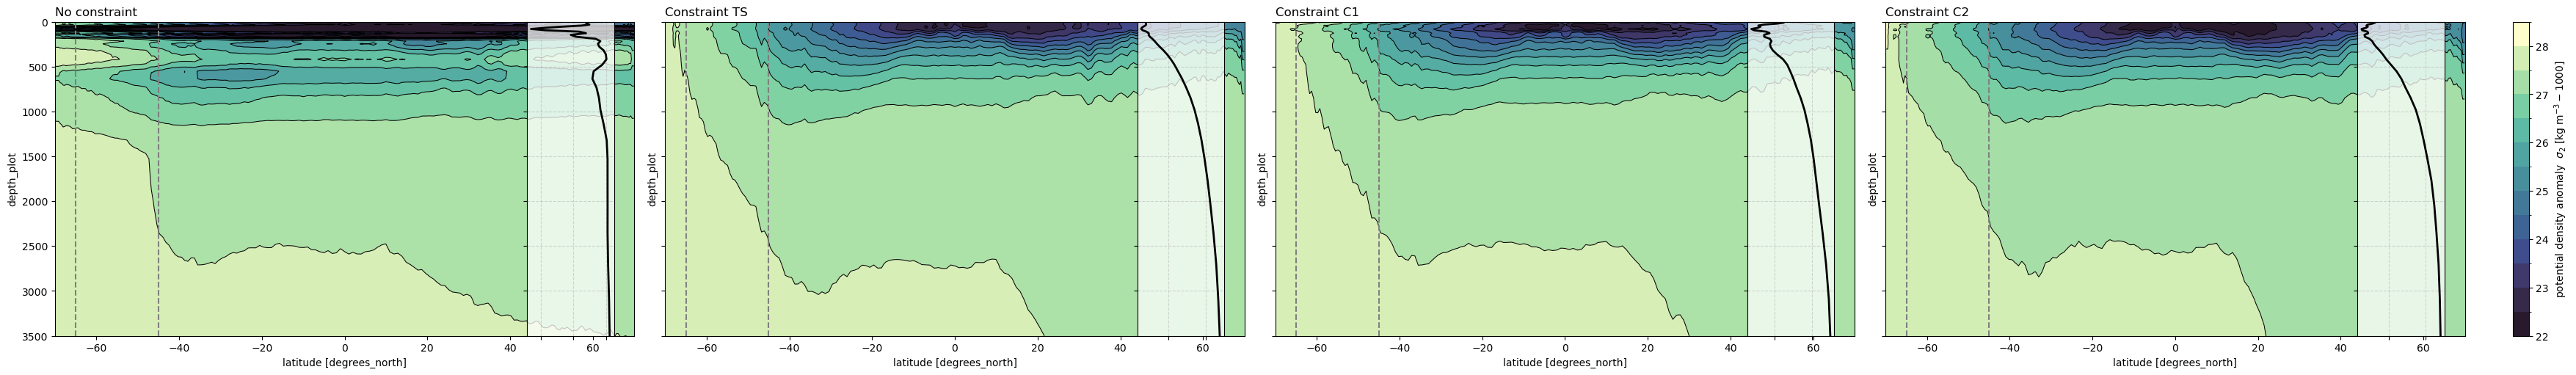

In [67]:
initial_states = '/lustre/fsn1/projects/rech/omr/romr004/data/'

fig, axs = plt.subplots(1,len(exps), figsize=(35, 5), sharey=True, constrained_layout=True)

plots = []
for i, exp in enumerate(exps) : 
    plots.append({'title' : f'{exp.description}', 'exp' : exp, 'path' : initial_states + exp.namelist['namrun']['cn_ocerst_in'] + '.nc', 'ax' : axs[i]})

for plot in plots:
    rn = prepare_restart(plot['exp'], plot['path'])
    sigma_mean = compute_sigma_mean(plot['exp'], rn)

    quadset = add_sigma_plot(plot['ax'], sigma_mean, plot['title'])
    
cbar = fig.colorbar(quadset, ax=axs, location='right', fraction=0.025, pad=0.02)
cbar.set_label(r'potential density anomaly  $\sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')   # optional label
fig.savefig('Results/figures/generated_states.png')
#fig.suptitle('Generated states')

In [66]:
ls 

Diffusion_Model/  DINO-Fusion.drawio  images/  README.md  Results/  scripts/


[PurePosixPath('/lustre/fsstor/projects/rech/omr/uym68qx/nemo_output/DINO/Dinoffusion/1_4degree/restart29/DINO_12960000_restart.nc')]
[PurePosixPath('/lustre/fsn1/projects/rech/omr/romr004/Blandine/DINO/Diffusion_runs/Constraint_no_C/restart0/DINO_11232000_restart.nc')]
[PurePosixPath('/lustre/fsn1/projects/rech/omr/romr004/Blandine/DINO/Diffusion_runs/Constraint_TS/restart0/DINO_11232000_restart.nc')]
[PurePosixPath('/lustre/fsn1/projects/rech/omr/uym68qx/DINO/Blandine/restart25_C1/DINO_11232000_restart.nc')]
[PurePosixPath('/lustre/fsn1/projects/rech/omr/uym68qx/DINO/Blandine/restart25_C2/DINO_11232000_restart.nc')]


/tmp/ipykernel_3178218/883156742.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 3500x500 with 9 Axes> than <Figure size 4500x500 with 11 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(quadset, ax=axs, location='right', fraction=0.025, pad=0.02)


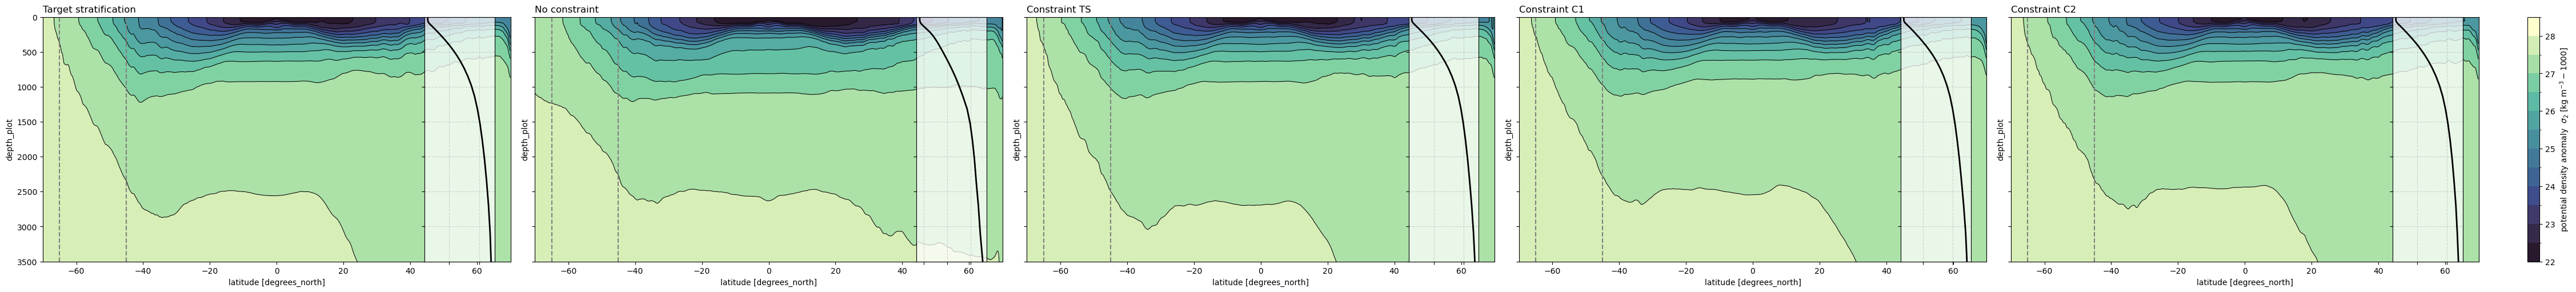

In [68]:
initial_states = '/lustre/fsn1/projects/rech/omr/romr004/data/'

fig, axs = plt.subplots(1,len(exps) + 1, figsize=(45, 5), sharey=True, constrained_layout=True)

plots = []
plots.append({'exp' : expR4, 'path' :  expR4.path + expR4.restarts[-1] +'/DINO_12960000_restart.nc', 'title' : 'Target stratification', 'ax' : axs[0]})

for i, exp in enumerate(exps) : 
    plots.append({'title' : f'{exp.description}', 'exp' : exp, 'path' : exp.path + exp.restarts[-1] +'/DINO_11232000_restart.nc', 'ax' : axs[i+1]})

for plot in plots:
    rn = prepare_restart(plot['exp'], plot['path'])
    sigma_mean = compute_sigma_mean(plot['exp'], rn)

    add_sigma_plot(plot['ax'], sigma_mean, plot['title'])

cbar = fig.colorbar(quadset, ax=axs, location='right', fraction=0.025, pad=0.02)
cbar.set_label(r'potential density anomaly  $\sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')   # optional label
fig.savefig('Results/figures/states_after_10y_integration.png')

#fig.suptitle('States after 10y integration')

In [12]:
expR4.restarts[-1] + 

['restart25', 'restart26', 'restart27', 'restart28', 'restart29']

'/lustre/fsstor/projects/rech/omr/uym68qx/nemo_output/DINO/Dinoffusion/1_4degree/restart29/DINO_12960000_restart.nc'

[PurePosixPath('/lustre/fsstor/projects/rech/omr/uym68qx/nemo_output/DINO/Dinoffusion/1_4degree/restart24/DINO_10800000_restart.nc')]


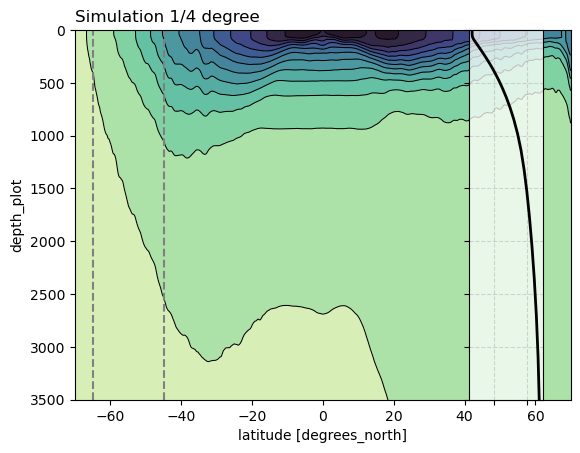

In [27]:
fig, ax = plt.subplots(1,1)
plot = {'exp' : expR4, 'path' :  expR4.path + expR4.restarts[-1] +'/DINO_12960000_restart.nc', 'title' : 'Target stratification', 'ax' : ax}
rn = prepare_restart(plot['exp'], plot['path'])
sigma_mean = compute_sigma_mean(plot['exp'], rn)

add_sigma_plot(plot['ax'], sigma_mean, plot['title'])

[PurePosixPath('/lustre/fsstor/projects/rech/omr/uym68qx/nemo_output/DINO/Dinoffusion/1_4degree/restart29/DINO_12960000_restart.nc')]


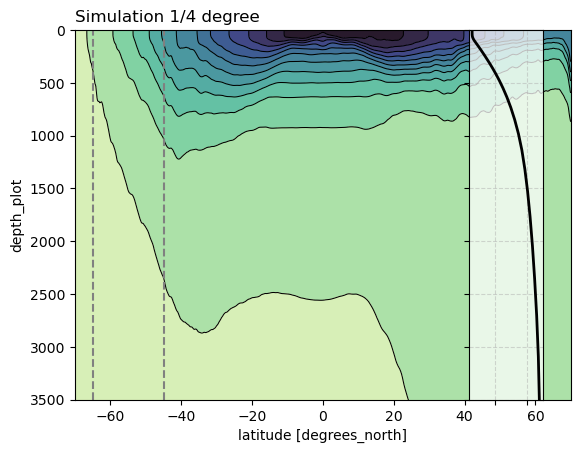

In [20]:
fig, ax = plt.subplots(1,1)
plot = {'exp' : expR4, 'path' :  expR4.path + expR4.restarts[-1] +'/DINO_12960000_restart.nc', 'title' : expR4.description, 'ax' : ax}
rn = prepare_restart(plot['exp'], plot['path'])
sigma_mean = compute_sigma_mean(plot['exp'], rn)

add_sigma_plot(plot['ax'], sigma_mean, plot['title'])